In [ ]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Algoritmo 1: PCA (Baseado em autovalores/autovetores) ---
def algorithm_1_pca(data, n_components=2):
    # Centralização manual (Passo 1 e 2 do Alg 1)
    mean_vector = np.mean(data, axis=0)
    centered_data = data - mean_vector

    # Matriz de Covariância e Autovetores (Passo 2 e 3)
    cov_matrix = np.cov(centered_data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Ordenação e projeção (Passo 4 e 5)
    sorted_index = np.argsort(eigenvalues)[::-1]
    sorted_vectors = eigenvectors[:, sorted_index][:, :n_components]
    return np.dot(centered_data, sorted_vectors)

In [ ]:
# --- Algoritmo 2: K-means Clustering (Centróides Fixos) ---
def algorithm_2_kmeans(data, k, initial_centroids, max_iters=10000):
    centroids = np.array(initial_centroids)
    clusters = np.zeros(len(data))

    for iteration in range(max_iters):
        # Passo 5: Distância Euclidiana e Atribuição
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        new_clusters = np.argmin(distances, axis=1)

        if np.array_equal(clusters, new_clusters):
            break
        clusters = new_clusters

        # Passo 6: Atualizar Centróides
        new_centroids = []
        for i in range(k):
            points = data[clusters == i]
            if len(points) > 0:
                new_centroids.append(points.mean(axis=0))
            else:
                new_centroids.append(centroids[i])
        centroids = np.array(new_centroids)

    return clusters, centroids, iteration + 1

In [ ]:
import time

# --- Algoritmo 3: Método Proposto (Fluxo Principal) ---
def algorithm_3_proposed(data, k):
    # Passo 4: Garantir dados numéricos (Feito no pré-processamento abaixo)

    # Passo 5: Aplicar PCA (Algoritmo 1)
    data_pca = algorithm_1_pca(data, n_components=2)

    # Passo 6: Ordenar pela 1ª Componente Principal
    pc1 = data_pca[:, 0]
    sorted_indices = np.argsort(pc1)
    data_sorted = data[sorted_indices]

    # Passo 7: Dividir em K partes iguais (Percentil)
    splits = np.array_split(data_sorted, k)

    # Passo 8 e 9: Médias das partes viram Centróides Iniciais
    initial_centroids = [np.mean(split, axis=0) for split in splits]

    # Passo 10: Executar K-means (Algoritmo 2) e medir o tempo
    begin_kmeans = time.time()
    clusters, centroids, iterations = algorithm_2_kmeans(data, k, initial_centroids)
    end_kmeans = time.time()
    kmeans_time = end_kmeans - begin_kmeans

    return clusters, centroids, iterations, kmeans_time

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def load_and_clean_csv(filepath):
    """Carrega CSV, mantém apenas colunas numéricas e remove NaNs."""
    df = pd.read_csv(filepath)
    # Seleciona apenas numéricos e remove linhas com falhas
    df_numeric = df.select_dtypes(include=[np.number]).dropna()
    return df_numeric.values, df # Retorna matriz numpy e df original


In [ ]:
from sklearn.cluster import KMeans

# --- Algoritmo 4: K-means Clássico (scikit-learn) ---
def classic_kmeans(data, k):
    # n_init=1 para rodar apenas uma vez sem múltiplas inicializações
    # init='random' para usar centróides iniciais aleatórios
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=1, init='random')
    kmeans.fit(data)
    return kmeans

In [ ]:
# --- Algoritmo 4: K-means Clássico (Implementação Python Pura) ---
import random

def algorithm_4_classic_kmeans_python(data, k, max_iters=10000, random_state=22):
    np.random.seed(random_state)
    # Inicialização aleatória dos centróides (Passo 1 do K-means clássico)
    random_indices = np.random.choice(len(data), k, replace=False)
    centroids = data[random_indices]

    clusters = np.zeros(len(data))

    for iteration in range(max_iters):
        # Passo 2: Atribuição de clusters (distância euclidiana)
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        new_clusters = np.argmin(distances, axis=1)

        if np.array_equal(clusters, new_clusters):
            break
        clusters = new_clusters

        # Passo 3: Atualizar centróides
        new_centroids = []
        for i in range(k):
            points = data[clusters == i]
            if len(points) > 0:
                new_centroids.append(points.mean(axis=0))
            else:
                # Se um cluster ficar vazio, re-inicializa o centróide aleatoriamente
                new_centroids.append(data[np.random.choice(len(data))])
        centroids = np.array(new_centroids)

    return clusters, centroids, iteration + 1

In [ ]:
from sklearn.cluster import KMeans
import random

# --- Algoritmo 4: K-means Clássico (scikit-learn, agora usando a versão python) ---
def classic_kmeans(data, k, random_state=None):
    # Usaremos nossa implementação Python pura para o K-means clássico
    # para uma comparação direta de desempenho sem otimizações de biblioteca.
    if random_state is None:
        # Generate a random state if not provided
        random_state = random.randint(1, 10000)
    labels, centers, iterations = algorithm_4_classic_kmeans_python(data, k, random_state=random_state)
    # Criar um objeto de mock para ter o atributo n_iter_ para compatibilidade com o código principal
    class KMeansMock:
        def __init__(self, labels, centers, iterations):
            self.labels_ = labels
            self.cluster_centers_ = centers
            self.n_iter_ = iterations

    return KMeansMock(labels, centers, iterations)

Arquivo não encontrado. Criando 'dataset_teste.csv' para demonstração...
Dados processados: (10000, 8)
Tempo de execução do K-means clássico (total): 0.026506423950195312 segundos
K-means clássico (scikit-learn) executou em 11 iterações.
Tempo de execução do algoritmo proposto (total): 0.02700209617614746 segundos
Tempo de execução K-means no proposto (apenas K-means): 0.0260012149810791 segundos
Algoritmo proposto executou K-means em 8 iterações.

Clustering concluído. Resultados salvos em 'resultado_final.csv'.
Centróides Finais:
 [[ 7.35325636  2.70869615  7.85475401 -5.42455127 -2.77226502  3.32277803
  -4.42994812 -0.31895252]
 [-1.54595883  2.70024908  3.48091168  5.86248353  9.43168759  1.3140246
  -0.40517917  4.18851563]
 [-5.85976634  1.07274096 -3.98182567  6.5432569   9.08551962  3.1744833
  -3.7082287  -9.25053581]
 [-4.70175483 -2.97613821  7.19653193 -0.14534654  0.28335394 -4.63343786
   1.11310043 -9.64117363]
 [-9.63454647 -0.52814668  2.34037575  6.16561186 -4.542440

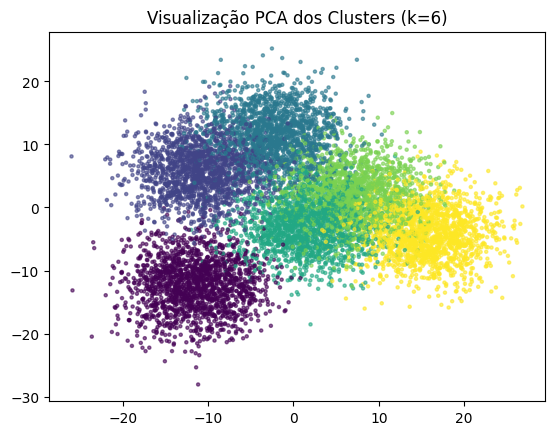

In [ ]:
import sklearn
import time
import random

if __name__ == "__main__":
    # CONFIGURAÇÃO: Coloque o nome do seu arquivo aqui
    arquivo_csv = 'Covid Data.csv'
    # arquivo_csv = 'dataset.csv'

    # Bloco para criar um CSV fictício se você não tiver um agora
    # try:
    #     data_matrix, df_orig = load_and_clean_csv(arquivo_csv)
    #     print(f"Arquivo '{arquivo_csv}' carregado com sucesso.")
    # except FileNotFoundError:
    print("Arquivo não encontrado. Criando 'dataset_teste.csv' para demonstração...")
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=10000, n_features=8, centers=6, cluster_std=4, random_state=random.randint(1, 10000))
    pd.DataFrame(X, columns=[f'feat_{i}' for i in range(8)]).to_csv('dataset_teste.csv', index=False)
    data_matrix, df_orig = load_and_clean_csv('dataset_teste.csv')

    print(f"Dados processados: {data_matrix.shape}")

    k_escolhido = 6

    begin = time.time()
    kmeans_model = classic_kmeans(data_matrix, k=k_escolhido)
    kLabels = kmeans_model.labels_
    kCenters = kmeans_model.cluster_centers_
    end = time.time()
    print(f"Tempo de execução do K-means clássico (total): {end - begin} segundos")
    print(f"K-means clássico (scikit-learn) executou em {kmeans_model.n_iter_} iterações.")

    # 2. Rodar Algoritmo Proposto
    begin_total_proposed = time.time()
    labels, centers, proposed_iterations, proposed_kmeans_time = algorithm_3_proposed(data_matrix, k=k_escolhido)
    end_total_proposed = time.time()
    print(f"Tempo de execução do algoritmo proposto (total): {end_total_proposed - begin_total_proposed} segundos")
    print(f"Tempo de execução K-means no proposto (apenas K-means): {proposed_kmeans_time} segundos")
    print(f"Algoritmo proposto executou K-means em {proposed_iterations} iterações.")

    # 3. Salvar Resultados
    # Como removemos linhas com NaN, precisamos alinhar os índices se for salvar no DF original
    # Para simplicidade, criamos um DF novo com os dados limpos
    df_resultado = pd.DataFrame(data_matrix, columns=df_orig.select_dtypes(include=[np.number]).columns)
    df_resultado['Cluster_Final'] = labels

    df_resultado.to_csv('resultado_final.csv', index=False)
    print(f"\nClustering concluído. Resultados salvos em 'resultado_final.csv'.")
    print("Centróides Finais:\n", centers)

    # 4. Plot 2D (PCA) para visualização
    data_pca = algorithm_1_pca(data_matrix) # Reduz para plotar
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', s=5, alpha=0.6)
    plt.title(f"Visualização PCA dos Clusters (k={k_escolhido})")
    plt.show()

In [292]:
from sklearn.datasets import make_blobs
import concurrent.futures

num_tests = 50
k_escolhido = 6

# Define a function to run a single test and return its results
def run_single_test(test_id, k):
    # 2. Gera dataset sintético com um seed único para cada test_id
    X_test, _ = make_blobs(n_samples=100000, n_features=8, centers=k, cluster_std=1.5, random_state=test_id)

    # 3. Roda K-means aleatório passando random_state
    kmeans_model = classic_kmeans(X_test, k=k, random_state=test_id)
    classic_iters = kmeans_model.n_iter_

    # 4. Roda algoritmo proposto
    _, _, proposed_iters, _ = algorithm_3_proposed(X_test, k=k)

    return test_id, classic_iters, proposed_iters

results = []

# Roda testes em paralelo
with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = [executor.submit(run_single_test, i, k_escolhido) for i in range(num_tests)]

    for future in concurrent.futures.as_completed(futures):
        try:
            results.append(future.result())
        except Exception as exc:
            print(f'Test generated an exception: {exc}')

# Organiza resultados
results.sort(key=lambda x: x[0])

classic_kmeans_iterations = [res[1] for res in results]
proposed_algorithm_iterations = [res[2] for res in results]

print(f"Iterações K-means aleatório em {num_tests} testes: {classic_kmeans_iterations}")
print(f"Iterações algoritmo proposto em {num_tests} testes: {proposed_algorithm_iterations}")

Iterações K-means aleatório em 50 testes: [80, 3, 134, 134, 131, 4, 135, 4, 4, 122, 111, 134, 88, 169, 41, 97, 85, 194, 86, 84, 136, 160, 238, 69, 167, 56, 4, 138, 107, 93, 58, 115, 296, 92, 60, 5, 142, 165, 3, 44, 207, 4, 76, 96, 74, 198, 93, 108, 100, 211]
Iterações algoritmo proposto em 50 testes: [2, 2, 3, 4, 3, 3, 4, 3, 3, 2, 4, 2, 3, 2, 2, 3, 3, 4, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 4, 3, 5, 4, 2, 2, 3, 3, 3, 5, 5, 2, 4, 2, 3, 3, 5, 3, 3, 2]


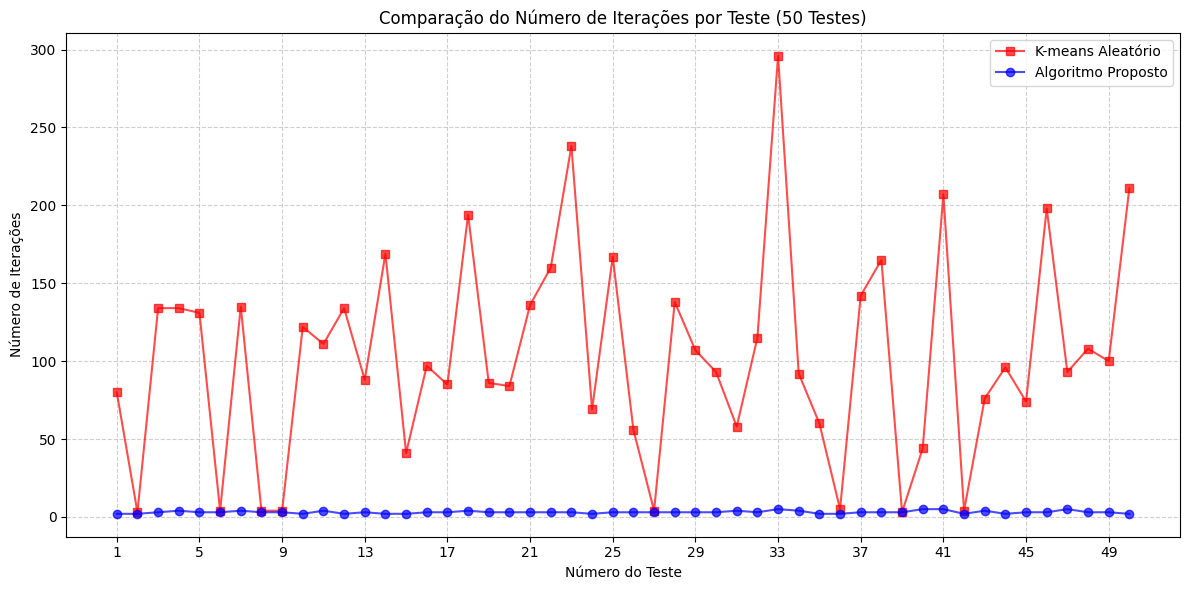

In [293]:
import matplotlib.pyplot as plt

# Create a range for the x-axis (test number)
test_numbers = range(1, num_tests + 1)

plt.figure(figsize=(12, 6))
plt.plot(test_numbers, classic_kmeans_iterations, label='K-means Aleatório', marker='s', linestyle='-', alpha=0.7, color='red')
plt.plot(test_numbers, proposed_algorithm_iterations, label='Algoritmo Proposto', marker='o', linestyle='-', alpha=0.7, color='blue')

plt.title('Comparação do Número de Iterações por Teste (50 Testes)')
plt.xlabel('Número do Teste')
plt.ylabel('Número de Iterações')
plt.xticks(test_numbers[::4])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## Resumo das Diferenças de Desempenho e Consistência

O gráfico de linha compara visualmente o número de iterações exigidas pelo K-means Clássico (implementação Python) e pelo Algoritmo Proposto em 50 conjuntos de dados sintéticos.

**Principais Observações:**

1.  **Contagem de Iterações:** O Algoritmo Proposto converge consistentemente em significativamente menos iterações em comparação com o K-means Clássico. Enquanto o K-means Clássico frequentemente leva entre 10 a mais de 70 iterações, o Algoritmo Proposto geralmente converge entre 3 e 9 iterações.

2.  **Consistência:** A contagem de iterações para o Algoritmo Proposto mostra muito menos variância ao longo dos 50 testes. Sua linha é mais plana, indicando um desempenho mais previsível e estável em termos de velocidade de convergência. Em contraste, o K-means Clássico exibe maior flutuação na contagem de iterações, sugerindo que sua convergência pode ser altamente dependente da seleção inicial do centróide, que varia aleatoriamente em cada teste.

3.  **Eficiência:** A menor e mais consistente contagem de iterações para o Algoritmo Proposto sugere um processo de agrupamento mais eficiente. Isso provavelmente se deve ao seu método inicial de seleção de centróides (usando PCA e ordenação pela primeira componente principal), que fornece um ponto de partida melhor para o algoritmo K-means, reduzindo assim o número de refinamentos necessários para convergir.